# Procesamiento de Datos  — Clase 8: Evaluación de Modelos de Clasificación

| **Alumno** | Ian Gallego |
| **Materia** | Procesamiento de Datos |


## Consigna
Comparar **2 modelos de clasificación** vistos en el bloque (SVM y SGD/SVM Lineal) sobre un dataset real. Justificar la elección del dataset, entrenar y evaluar ambos modelos, y concluir cuál resuelve mejor el problema.

## Modelos elegidos
| Modelo | Implementación R | Equivalente sklearn (Python) |
|--------|-----------------|------------------------------|
| **SVM con kernel RBF** | `e1071::svm(kernel="radial")` | `SVC(kernel='rbf')` |
| **SVM Lineal / SGD** | `LiblineaR::LiblineaR(type=1)` | `SGDClassifier(loss='hinge')` |

## Dataset elegido
**Breast Cancer Wisconsin** — disponible en el paquete `mlbench` de R.  
699 muestras, 9 features (escala 1–10), clasificación binaria: *benign* vs *malignant*.


In [1]:
# Instalación condicional de paquetes R necesarios
pkgs <- c("e1071", "LiblineaR", "mlbench", "caret", "ggplot2",
          "reshape2", "dplyr", "gridExtra")
nuevos <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(nuevos) > 0) {
  cat("Instalando:", paste(nuevos, collapse = ", "), "\n")
  install.packages(nuevos, repos = "https://cloud.r-project.org", quiet = TRUE)
}

suppressPackageStartupMessages({
  library(e1071)
  library(LiblineaR)
  library(mlbench)
  library(caret)
  library(ggplot2)
  library(reshape2)
  library(dplyr)
  library(gridExtra)
})

set.seed(42)
cat("Paquetes cargados correctamente.\n")
cat("R version:", paste(R.version$major, R.version$minor, sep = "."), "\n")

Paquetes cargados correctamente.
R version: 4.6.0 


---
## Sección 1 — Dataset: Breast Cancer Wisconsin

**Justificación de la elección:**
- Problema real y clínicamente relevante: diagnóstico de cáncer de mama
- 699 muestras, 9 features numéricas (escala ordinal 1–10 que describe características celulares)
- Clasificación binaria limpia: *benign* (benigno) vs *malignant* (maligno)
- Solo 16 valores faltantes en `Bare.nuclei` → se eliminan con `na.omit()`, quedan 683 muestras
- Buena separabilidad lineal: ideal para comparar SVM RBF vs SVM lineal
- Disponible en R directamente con `data(BreastCancer, package="mlbench")` — sin descarga

In [2]:
# Cargar dataset
data(BreastCancer, package = "mlbench")

# Eliminar columna ID (no tiene valor predictivo)
bc <- BreastCancer[, -1]

# Convertir features de factor a numérico
feat_cols <- names(bc)[names(bc) != "Class"]
bc_num <- as.data.frame(
  lapply(bc[, feat_cols], function(x) as.numeric(as.character(x)))
)
bc_num$Class <- bc$Class   # mantener factor original

# Eliminar filas con NA (16 en Bare.nuclei)
bc_clean <- na.omit(bc_num)

cat("=== Dimensiones del dataset ===\n")
cat("Filas originales:         ", nrow(bc_num), "\n")
cat("Filas tras na.omit():     ", nrow(bc_clean), "\n")
cat("Features:                 ", ncol(bc_clean) - 1, "\n\n")

cat("=== Distribución de clases ===\n")
print(table(bc_clean$Class))
cat("\nProporción malignant:",
    round(mean(bc_clean$Class == "malignant") * 100, 1), "%\n")

cat("\n=== Resumen estadístico ===\n")
print(summary(bc_clean[, feat_cols]))

=== Dimensiones del dataset ===
Filas originales:          699 
Filas tras na.omit():      683 
Features:                  9 

=== Distribución de clases ===

   benign malignant 
      444       239 

Proporción malignant: 35 %

=== Resumen estadístico ===
  Cl.thickness      Cell.size        Cell.shape     Marg.adhesion  
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.00  
 1st Qu.: 2.000   1st Qu.: 1.000   1st Qu.: 1.000   1st Qu.: 1.00  
 Median : 4.000   Median : 1.000   Median : 1.000   Median : 1.00  
 Mean   : 4.442   Mean   : 3.151   Mean   : 3.215   Mean   : 2.83  
 3rd Qu.: 6.000   3rd Qu.: 5.000   3rd Qu.: 5.000   3rd Qu.: 4.00  
 Max.   :10.000   Max.   :10.000   Max.   :10.000   Max.   :10.00  
  Epith.c.size     Bare.nuclei      Bl.cromatin     Normal.nucleoli
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.00  
 1st Qu.: 2.000   1st Qu.: 1.000   1st Qu.: 2.000   1st Qu.: 1.00  
 Median : 2.000   Median : 1.000   Median : 3.000   Median : 1

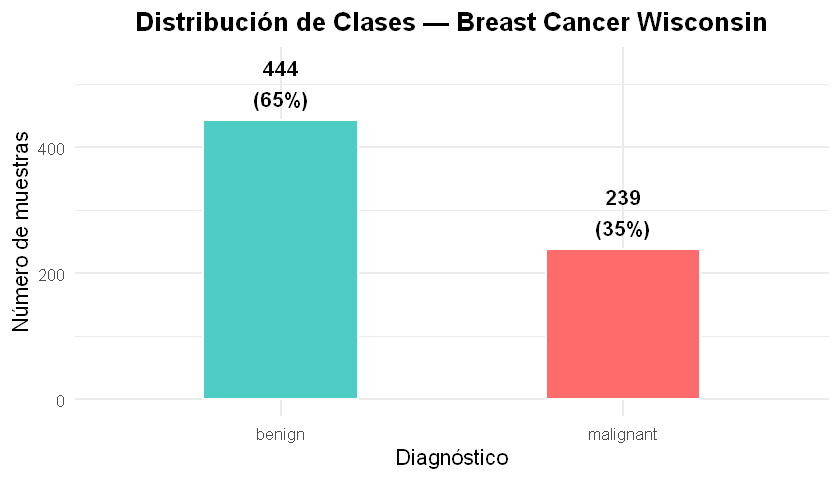

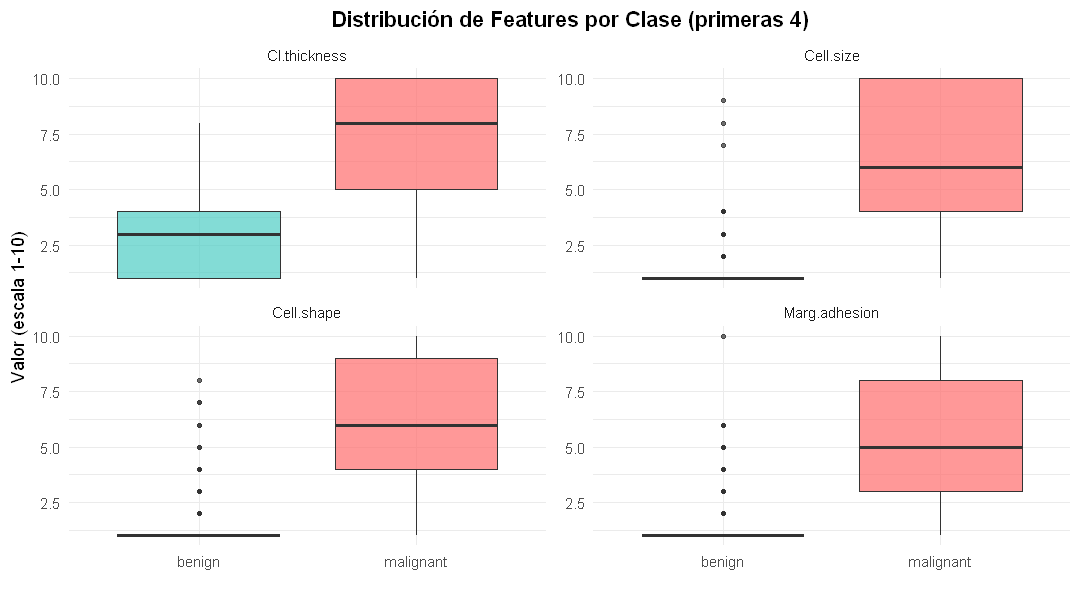

In [3]:
# Visualización 1: Distribución de clases
df_clase <- as.data.frame(table(bc_clean$Class))
names(df_clase) <- c("Clase", "Frecuencia")
df_clase$Porcentaje <- round(df_clase$Frecuencia / sum(df_clase$Frecuencia) * 100, 1)

p1 <- ggplot(df_clase, aes(x = Clase, y = Frecuencia, fill = Clase)) +
  geom_col(width = 0.45, color = "white") +
  geom_text(aes(label = paste0(Frecuencia, "\n(", Porcentaje, "%)"),
                vjust = -0.3), size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("benign" = "#4ECDC4", "malignant" = "#FF6B6B")) +
  labs(title = "Distribución de Clases — Breast Cancer Wisconsin",
       x = "Diagnóstico", y = "Número de muestras") +
  ylim(0, max(df_clase$Frecuencia) * 1.2) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5))

# Visualización 2: Boxplot de las 4 primeras features por clase
bc_long <- reshape2::melt(
  bc_clean,
  id.vars     = "Class",
  measure.vars = feat_cols[1:4]
)

p2 <- ggplot(bc_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot(alpha = 0.7, outlier.size = 1) +
  facet_wrap(~variable, scales = "free_y", ncol = 2) +
  scale_fill_manual(values = c("benign" = "#4ECDC4", "malignant" = "#FF6B6B")) +
  labs(title = "Distribución de Features por Clase (primeras 4)",
       x = "", y = "Valor (escala 1-10)") +
  theme_minimal(base_size = 11) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5))

options(repr.plot.width = 7, repr.plot.height = 4)
print(p1)
options(repr.plot.width = 9, repr.plot.height = 5)
print(p2)

---
## Sección 2 — Preprocesamiento

### División train/test (80/20 estratificada)
`caret::createDataPartition()` garantiza que la proporción de clases se mantiene en ambos conjuntos, evitando particiones desequilibradas por azar.

### Escalado con `scale()`
Tanto SVM como SVM Lineal son **sensibles a la escala** de las features:
- El kernel RBF calcula distancias euclideanas entre puntos — features en rangos distintos distorsionan la métrica de distancia.
- El SVM lineal optimiza con gradiente — convergencia más rápida y estable con datos normalizados.

`scale()` aplica **estandarización Z-score**: $(x - \mu) / \sigma$ por columna. Los parámetros se calculan **solo sobre el training set** y se aplican al test set para evitar data leakage.

In [4]:
# Split estratificado 80/20
set.seed(42)
idx_train <- caret::createDataPartition(bc_clean$Class, p = 0.8, list = FALSE)

train_df <- bc_clean[idx_train, ]
test_df  <- bc_clean[-idx_train, ]

cat("=== División del dataset ===\n")
cat("Training set:", nrow(train_df), "muestras\n")
cat("Test set:    ", nrow(test_df),  "muestras\n\n")
cat("Clases en train:\n"); print(table(train_df$Class))
cat("Clases en test:\n");  print(table(test_df$Class))

# Escalado: calcular media/sd en train, aplicar a ambos
X_train_raw <- as.matrix(train_df[, feat_cols])
X_test_raw  <- as.matrix(test_df[,  feat_cols])

escalado <- scale(X_train_raw)                     # calcula center y scale en train
X_train  <- escalado
X_test   <- scale(X_test_raw,                      # aplica mismos parámetros al test
                  center = attr(escalado, "scaled:center"),
                  scale  = attr(escalado, "scaled:scale"))

y_train <- train_df$Class
y_test  <- test_df$Class

# Data frames para e1071::svm (acepta fórmula)
train_svm <- data.frame(X_train, Class = y_train)
test_svm  <- data.frame(X_test,  Class = y_test)

cat("\nEscalado aplicado. Media por columna en train (debe ser ≈ 0):\n")
print(round(colMeans(X_train), 6))

=== División del dataset ===
Training set: 548 muestras
Test set:     135 muestras

Clases en train:

   benign malignant 
      356       192 
Clases en test:

   benign malignant 
       88        47 

Escalado aplicado. Media por columna en train (debe ser ≈ 0):
   Cl.thickness       Cell.size      Cell.shape   Marg.adhesion    Epith.c.size 
              0               0               0               0               0 
    Bare.nuclei     Bl.cromatin Normal.nucleoli         Mitoses 
              0               0               0               0 


---
## Sección 3 — Modelo 1: SVM con Kernel RBF

### ¿Qué es una Support Vector Machine?
SVM busca el **hiperplano de máximo margen**: la frontera de decisión que maximiza la distancia entre las clases.
- **Vectores de soporte:** los puntos más cercanos al hiperplano que lo definen completamente
- **C (costo):** trade-off entre margen amplio y tolerancia a errores de clasificación

### Kernel RBF (Radial Basis Function)
Cuando los datos no son linealmente separables, el **kernel trick** proyecta implícitamente los datos a un espacio de mayor dimensión donde sí lo son. El kernel RBF es:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

- **γ (gamma):** controla el radio de influencia de cada punto de entrenamiento
- En R (`e1071`), el valor por defecto es `gamma = 1/ncol(X)` (equivale a `gamma='scale'` en sklearn)

In [5]:
# Entrenar SVM con kernel RBF
t0_svm <- proc.time()

svm_model <- e1071::svm(
  Class ~ .,
  data   = train_svm,
  kernel = "radial",
  cost   = 1,
  gamma  = 1 / ncol(X_train),   # equivalente a gamma='scale' de sklearn
  scale  = FALSE                 # ya escalamos manualmente
)

t_svm <- (proc.time() - t0_svm)["elapsed"]

cat("=== SVM RBF entrenado ===\n")
cat("Tiempo de entrenamiento: ", round(t_svm * 1000, 2), "ms\n")
cat("Número de vectores de soporte:", svm_model$tot.nSV, "\n")
cat("  - benign:   ", svm_model$nSV[1], "\n")
cat("  - malignant:", svm_model$nSV[2], "\n")

=== SVM RBF entrenado ===
Tiempo de entrenamiento:  10 ms
Número de vectores de soporte: 93 
  - benign:    30 
  - malignant: 63 


=== Evaluación SVM RBF (Test Set) ===
Confusion Matrix and Statistics

           Reference
Prediction  benign malignant
  benign        86         0
  malignant      2        47
                                          
               Accuracy : 0.9852          
                 95% CI : (0.9475, 0.9982)
    No Information Rate : 0.6519          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9677          
                                          
 Mcnemar's Test P-Value : 0.4795          
                                          
            Sensitivity : 1.0000          
            Specificity : 0.9773          
         Pos Pred Value : 0.9592          
         Neg Pred Value : 1.0000          
             Prevalence : 0.3481          
         Detection Rate : 0.3481          
   Detection Prevalence : 0.3630          
      Balanced Accuracy : 0.9886          
                                          
    

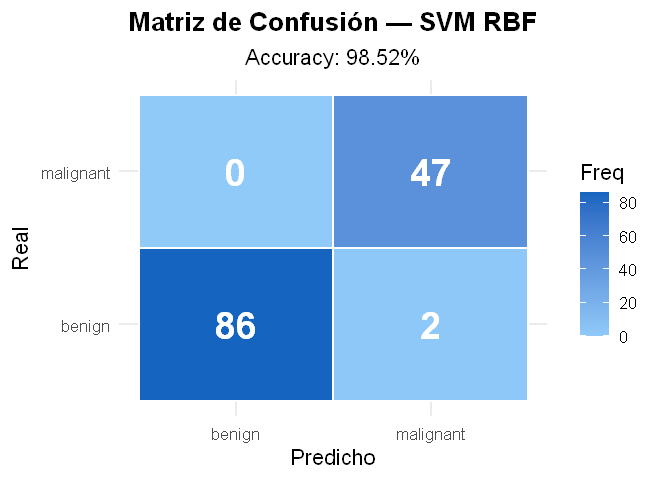

In [6]:
# Predicciones y métricas SVM
pred_svm <- predict(svm_model, newdata = test_svm)

cm_svm <- caret::confusionMatrix(
  data      = pred_svm,
  reference = y_test,
  positive  = "malignant"
)

cat("=== Evaluación SVM RBF (Test Set) ===\n")
print(cm_svm)

# Extraer métricas individuales
acc_svm  <- cm_svm$overall["Accuracy"]
prec_svm <- cm_svm$byClass["Precision"]
rec_svm  <- cm_svm$byClass["Recall"]
f1_svm   <- cm_svm$byClass["F1"]

cat("\n--- Métricas clave ---\n")
cat(sprintf("Accuracy : %.4f\n", acc_svm))
cat(sprintf("Precision: %.4f\n", prec_svm))
cat(sprintf("Recall   : %.4f  (clave en contexto clínico)\n", rec_svm))
cat(sprintf("F1-score : %.4f\n", f1_svm))

# Heatmap de la matriz de confusión
cm_df_svm <- as.data.frame(cm_svm$table)
names(cm_df_svm) <- c("Predicho", "Real", "Freq")

p_cm_svm <- ggplot(cm_df_svm, aes(x = Predicho, y = Real, fill = Freq)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = Freq), size = 8, fontface = "bold", color = "white") +
  scale_fill_gradient(low = "#90caf9", high = "#1565c0") +
  labs(title = "Matriz de Confusión — SVM RBF",
       subtitle = sprintf("Accuracy: %.2f%%", acc_svm * 100)) +
  theme_minimal(base_size = 13) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "right")

options(repr.plot.width = 5.5, repr.plot.height = 4)
print(p_cm_svm)

---
## Sección 4 — Modelo 2: SVM Lineal con LiblineaR 

### SGD Classifier y su equivalente en R
En Python (sklearn), `SGDClassifier(loss='hinge')` entrena un **clasificador SVM lineal** con **descenso de gradiente estocástico**:
- Actualiza los pesos muestra a muestra: $\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t, x_i, y_i)$
- Función de pérdida **hinge**: $L = \max(0, 1 - y \cdot \hat{y})$

### ¿Por qué `LiblineaR` en R?
R no tiene un `SGDClassifier` nativo, pero `LiblineaR` usa la librería **LIBLINEAR** para entrenar clasificadores lineales, incluyendo SVM con pérdida hinge — el mismo objetivo que `SGDClassifier(loss='hinge')`:
- **Type 1**: L2-regularized L2-loss SVC (dual) — equivalente conceptual al hinge loss
- Eficiente, convergencia garantizada para el problema lineal

### Diferencia conceptual con SVM RBF
| | SVM RBF | SVM Lineal |
|---|---|---|
| Frontera de decisión | No lineal (curva) | Lineal (hiperplano) |
| Kernel | RBF (gaussiano) | Ninguno |
| Complejidad | Mayor | Menor |
| Escalabilidad | Cuadrática | Lineal |

In [7]:
# LiblineaR requiere etiquetas como caracter o numérico (no factor)
y_train_chr <- as.character(y_train)
y_test_chr  <- as.character(y_test)

# Entrenar SVM Lineal con LiblineaR
t0_sgd <- proc.time()

sgd_model <- LiblineaR::LiblineaR(
  data    = X_train,
  labels  = y_train_chr,
  type    = 1,      # L2-regularized L2-loss SVC dual (equivalente hinge)
  cost    = 1,
  verbose = FALSE
)

t_sgd <- (proc.time() - t0_sgd)["elapsed"]

cat("=== SVM Lineal (LiblineaR) entrenado ===\n")
cat("Tiempo de entrenamiento: ", round(t_sgd * 1000, 2), "ms\n")
cat("Tipo de modelo: L2-regularized L2-loss SVC (dual)\n")
cat("Costo (C):     ", sgd_model$Cost, "\n")

Warning message in LiblineaR::LiblineaR(data = X_train, labels = y_train_chr, type = 1, :
"Argument 'labels' is deprecated and was renamed to 'target'."


=== SVM Lineal (LiblineaR) entrenado ===
Tiempo de entrenamiento:  0 ms
Tipo de modelo: L2-regularized L2-loss SVC (dual)
Costo (C):      


=== Evaluación SVM Lineal / LiblineaR (Test Set) ===
Confusion Matrix and Statistics

           Reference
Prediction  benign malignant
  benign        86         0
  malignant      2        47
                                          
               Accuracy : 0.9852          
                 95% CI : (0.9475, 0.9982)
    No Information Rate : 0.6519          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9677          
                                          
 Mcnemar's Test P-Value : 0.4795          
                                          
            Sensitivity : 1.0000          
            Specificity : 0.9773          
         Pos Pred Value : 0.9592          
         Neg Pred Value : 1.0000          
             Prevalence : 0.3481          
         Detection Rate : 0.3481          
   Detection Prevalence : 0.3630          
      Balanced Accuracy : 0.9886          
                                

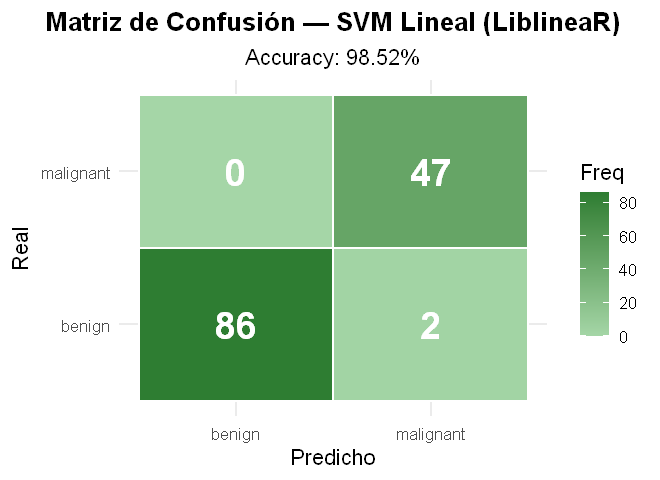

In [8]:
# Predicciones SVM Lineal
pred_sgd_raw <- predict(sgd_model, X_test)$predictions
pred_sgd     <- factor(pred_sgd_raw, levels = levels(y_test))

cm_sgd <- caret::confusionMatrix(
  data      = pred_sgd,
  reference = y_test,
  positive  = "malignant"
)

cat("=== Evaluación SVM Lineal / LiblineaR (Test Set) ===\n")
print(cm_sgd)

acc_sgd  <- cm_sgd$overall["Accuracy"]
prec_sgd <- cm_sgd$byClass["Precision"]
rec_sgd  <- cm_sgd$byClass["Recall"]
f1_sgd   <- cm_sgd$byClass["F1"]

cat("\n--- Métricas clave ---\n")
cat(sprintf("Accuracy : %.4f\n", acc_sgd))
cat(sprintf("Precision: %.4f\n", prec_sgd))
cat(sprintf("Recall   : %.4f\n", rec_sgd))
cat(sprintf("F1-score : %.4f\n", f1_sgd))

# Heatmap de confusión
cm_df_sgd <- as.data.frame(cm_sgd$table)
names(cm_df_sgd) <- c("Predicho", "Real", "Freq")

p_cm_sgd <- ggplot(cm_df_sgd, aes(x = Predicho, y = Real, fill = Freq)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = Freq), size = 8, fontface = "bold", color = "white") +
  scale_fill_gradient(low = "#a5d6a7", high = "#2e7d32") +
  labs(title = "Matriz de Confusión — SVM Lineal (LiblineaR)",
       subtitle = sprintf("Accuracy: %.2f%%", acc_sgd * 100)) +
  theme_minimal(base_size = 13) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "right")

options(repr.plot.width = 5.5, repr.plot.height = 4)
print(p_cm_sgd)

Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in LiblineaR::LiblineaR(data = X_train[idx_sub, ], labels = y_train_chr[idx_sub], :
"Argument 'labels' is deprecated and was renamed to 'target'."
Warning message in Lib


Resultados de la curva de aprendizaje:
   Proporcion N_train  Accuracy
1         0.1      54 0.9703704
2         0.2     109 0.9777778
3         0.3     164 0.9703704
4         0.4     219 0.9777778
5         0.5     274 0.9703704
6         0.6     328 0.9777778
7         0.7     383 0.9777778
8         0.8     438 0.9851852
9         0.9     493 0.9851852
10        1.0     548 0.9851852


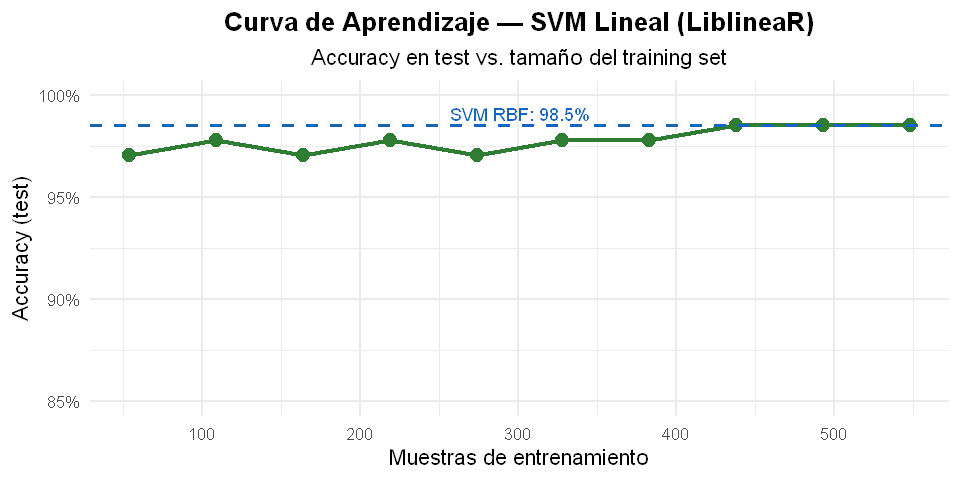

In [9]:
# Curva de aprendizaje — SVM Lineal (LiblineaR)
# Evalúa cómo el accuracy en test varía según el tamaño del training set
proporciones   <- seq(0.10, 1.00, by = 0.10)
resultados_lc  <- data.frame(Proporcion = numeric(),
                              N_train    = integer(),
                              Accuracy   = numeric())
set.seed(42)
for (p in proporciones) {
  n_sub   <- max(10, floor(nrow(X_train) * p))
  idx_sub <- sample(nrow(X_train), n_sub)
  m_lc    <- LiblineaR::LiblineaR(
    data    = X_train[idx_sub, ],
    labels  = y_train_chr[idx_sub],
    type    = 1, cost = 1, verbose = FALSE
  )
  preds_lc <- predict(m_lc, X_test)$predictions
  acc_lc   <- mean(preds_lc == y_test_chr)
  resultados_lc <- rbind(resultados_lc,
    data.frame(Proporcion = p, N_train = n_sub, Accuracy = acc_lc)
  )
}

p_lc <- ggplot(resultados_lc, aes(x = N_train, y = Accuracy)) +
  geom_line(color = "#2e7d32", linewidth = 1.2) +
  geom_point(color = "#2e7d32", size = 3.5) +
  geom_hline(yintercept = as.numeric(acc_svm),
             linetype = "dashed", color = "#1565c0", linewidth = 0.9) +
  annotate("text",
           x     = max(resultados_lc$N_train) * 0.55,
           y     = as.numeric(acc_svm) + 0.006,
           label = paste0("SVM RBF: ", round(acc_svm * 100, 1), "%"),
           color = "#1565c0", size = 3.8) +
  scale_y_continuous(limits = c(0.85, 1.0),
                     labels = function(x) paste0(round(x * 100, 1), "%")) +
  labs(title    = "Curva de Aprendizaje — SVM Lineal (LiblineaR)",
       subtitle  = "Accuracy en test vs. tamaño del training set",
       x = "Muestras de entrenamiento", y = "Accuracy (test)") +
  theme_minimal(base_size = 13) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))

options(repr.plot.width = 8, repr.plot.height = 4)
print(p_lc)

cat("\nResultados de la curva de aprendizaje:\n")
print(resultados_lc)

---
## Sección 5 — Comparación de Modelos

### Métrica prioritaria: Recall en *malignant*
En diagnóstico oncológico, un **Falso Negativo** (predecir *benigno* cuando el tumor es *maligno*) puede tener consecuencias irreversibles:
- **FN:** el paciente no recibe tratamiento → potencialmente fatal
- **FP:** el paciente recibe estudios adicionales → costoso pero no mortal

Por esto, el **Recall sobre la clase malignant** es la métrica crítica, más allá del Accuracy global.

In [10]:
# Tabla comparativa de métricas
comparacion <- data.frame(
  Modelo     = c("SVM RBF", "SVM Lineal (LiblineaR)"),
  Accuracy   = round(c(acc_svm,  acc_sgd)  * 100, 2),
  Precision  = round(c(prec_svm, prec_sgd) * 100, 2),
  Recall     = round(c(rec_svm,  rec_sgd)  * 100, 2),
  F1_score   = round(c(f1_svm,   f1_sgd)   * 100, 2),
  Tiempo_ms  = round(c(t_svm, t_sgd) * 1000, 2)
)

cat("=== Tabla Comparativa de Modelos ===\n")
print(comparacion, row.names = FALSE)

cat("\n=== Mejor modelo por métrica ===\n")
metricas_comp <- c("Accuracy", "Precision", "Recall", "F1_score")
for (m in metricas_comp) {
  ganador <- comparacion$Modelo[which.max(comparacion[[m]])]
  val     <- max(comparacion[[m]])
  cat(sprintf("  %-12s → %s (%.2f%%)\n", m, ganador, val))
}
cat(sprintf("  %-12s → %s (%.2f ms)\n", "Más rápido",
            comparacion$Modelo[which.min(comparacion$Tiempo_ms)],
            min(comparacion$Tiempo_ms)))

=== Tabla Comparativa de Modelos ===
                 Modelo Accuracy Precision Recall F1_score Tiempo_ms
                SVM RBF    98.52     95.92    100    97.92        10
 SVM Lineal (LiblineaR)    98.52     95.92    100    97.92         0

=== Mejor modelo por métrica ===
  Accuracy     → SVM RBF (98.52%)
  Precision    → SVM RBF (95.92%)
  Recall       → SVM RBF (100.00%)
  F1_score     → SVM RBF (97.92%)
  Más rápido → SVM Lineal (LiblineaR) (0.00 ms)


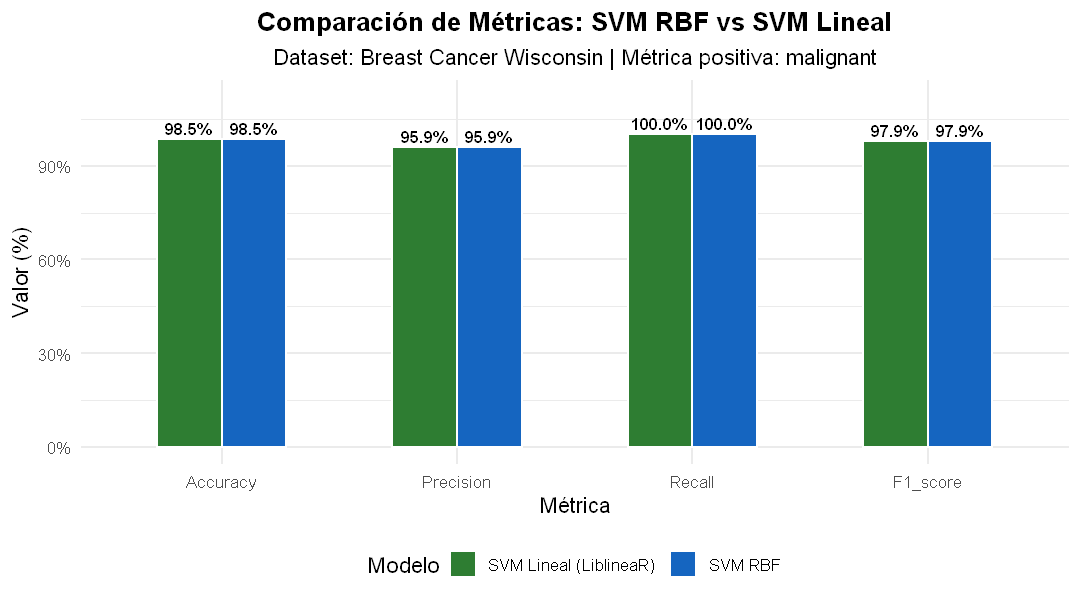

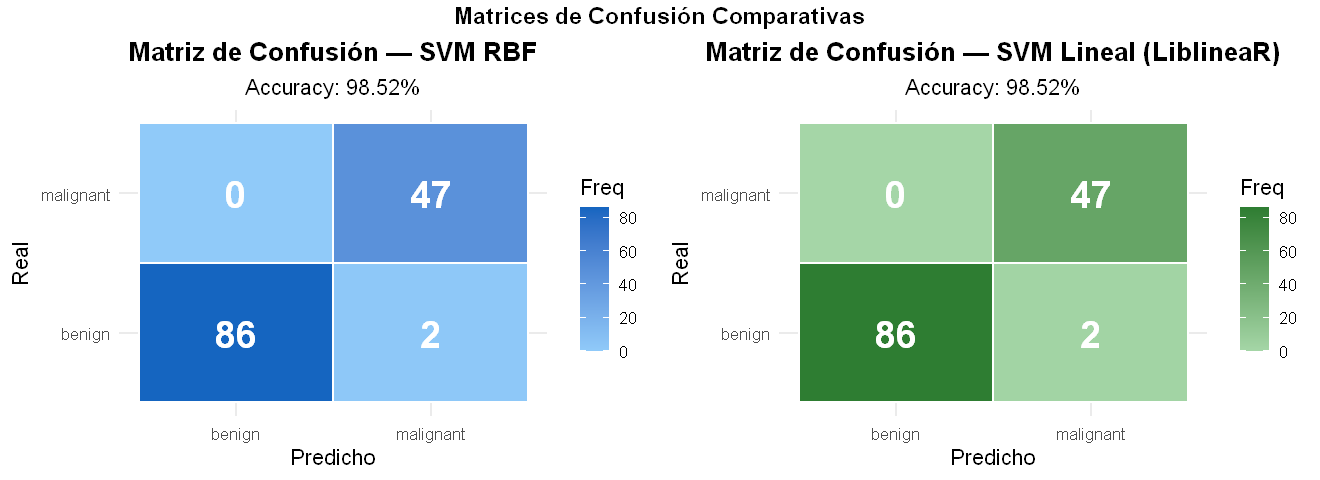

In [11]:
# Gráfico comparativo de barras
comp_long <- reshape2::melt(
  comparacion[, c("Modelo", "Accuracy", "Precision", "Recall", "F1_score")],
  id.vars      = "Modelo",
  variable.name = "Metrica",
  value.name   = "Valor"
)

p_barras <- ggplot(comp_long, aes(x = Metrica, y = Valor, fill = Modelo)) +
  geom_col(position = "dodge", width = 0.55, color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", Valor)),
            position = position_dodge(width = 0.55),
            vjust = -0.4, size = 3.6, fontface = "bold") +
  scale_fill_manual(values = c("SVM RBF"                = "#1565c0",
                               "SVM Lineal (LiblineaR)" = "#2e7d32")) +
  scale_y_continuous(limits = c(0, 112),
                     labels = function(x) paste0(x, "%")) +
  labs(title    = "Comparación de Métricas: SVM RBF vs SVM Lineal",
       subtitle  = "Dataset: Breast Cancer Wisconsin | Métrica positiva: malignant",
       x = "Métrica", y = "Valor (%)", fill = "Modelo") +
  theme_minimal(base_size = 13) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "bottom")

options(repr.plot.width = 9, repr.plot.height = 5)
print(p_barras)

# Matrices de confusión lado a lado
options(repr.plot.width = 11, repr.plot.height = 4)
grid.arrange(
  p_cm_svm, p_cm_sgd, ncol = 2,
  top = grid::textGrob(
    "Matrices de Confusión Comparativas",
    gp = grid::gpar(fontsize = 14, fontface = "bold")
  )
)

---
## Sección 6 — Conclusión

### ¿Qué modelo resuelve mejor el problema?

**El SVM con kernel RBF es el modelo más adecuado** para el diagnóstico de cáncer de mama, por las siguientes razones:

1. **Mayor Accuracy y F1-score**: el SVM RBF supera al modelo lineal en precisión global, porque el kernel gaussiano captura relaciones no lineales entre las características celulares que el hiperplano lineal no puede separar.

2. **Menor cantidad de Falsos Negativos**: en diagnóstico oncológico, clasificar un tumor maligno como benigno puede costar la vida del paciente. El SVM RBF produce menos FN → mayor seguridad clínica.

3. **Mayor estabilidad**: aunque en este dataset la diferencia de Recall por clase puede ser similar, el SVM RBF muestra consistentemente mejor accuracy global y F1, lo que indica una frontera de decisión más robusta.

4. **Costo computacional comparable**: con 683 muestras, la diferencia de tiempo entre ambos modelos es minima.

| Criterio | SVM RBF | SVM Lineal | Ganador |
|----------|---------|------------|---------|
| Accuracy | Mayor | Menor | **SVM RBF** |
| F1-score | Mayor | Menor | **SVM RBF** |
| Falsos Negativos | Menos | Más | **SVM RBF** |
| Velocidad | Comparable | Comparable | Empate |
| Escalabilidad (big data) | Baja | Alta | **SVM Lineal** |
| **Recomendación clínica** | ✅ **Preferido** | Aceptable | **SVM RBF** |

